---
numbering: false
---

# 9.3. Markov Chains and Adjacency Matrices

To extend what we've seen over the past two sections, I'll introduce a simplified version of the PageRank problem, first discussed in [Chapter 9.1](01-eigenvalues-eigenvectors.ipynb). This will allow me to highlight a key property of eigenvalues and eigenvectors: that they can be used to understand the long-term behavior of a system.

---

## The Game

That sounds abstract – what is a system, and what is long-term behavior? Let's illustrate with an example. "The Game" refers to the annual football game between Michigan and Ohio State. Let's suppose that:
- If **Michigan** wins in year $k$, there's an 80\% chance we win again in year $k+1$, and a 20\% chance that Ohio State wins in year $k+1$.
- If **Ohio State** wins in year $k$, there's a 70\% chance they win again in year $k+1$, and a 30\% chance that Michigan wins in year $k+1$.

**Question: In the long-run, what percentage of the time does Michigan win?** Perhaps a more approachable way of phrasing this is, what is the (unconditional) probability that Michigan wins a particular game?

This system is an example of a **Markov chain**, in which the probabilities of transitioning between states don't change over time. In words, the **Markov property** says that once we know the current state, the next state depends only on where we are now, not on the full history of how we got there. So for this example, once we know who won this year, the probability of next year's winner doesn't depend on who won two years ago, three years ago, and so on. Here, a "state" is the outcome of the game in a particular year. The probabilities described above are fixed: the chance Michigan wins in year 100 given they won in year 99 is 80\%, and the chance they win in year 55555 given they won in year 55554 is also 80\%.

It's often useful to visualize Markov chains using a **state diagram**, which is a directed graph in which each node represents a state, and each edge represents a transition between states. Each edge is labeled with the probability of the transition.

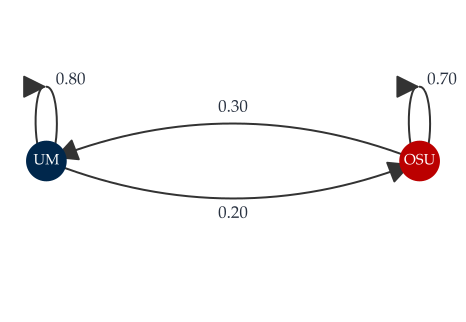

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
sns.set_context("poster")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Define transition probabilities for a Markov process (directed transitions)
# Rows: from, Columns: to
#      UM    OSU  
# UM [ 0.8 , 0.2 ]
# OSU[ 0.7 , 0.3 ]
transition = {
    ("UM", "UM"): 0.8,
    ("UM", "OSU"): 0.2,
    ("OSU", "UM"): 0.3,
    ("OSU", "OSU"): 0.7
}

# Create a directed graph
G = nx.DiGraph()
G.add_nodes_from(["UM", "OSU"])
for (src, dst), w in transition.items():
    G.add_edge(dst, src, weight=w)

# Positions: UM left, OSU right
pos = {"UM": [0, 0], "OSU": [2, 0]}
node_colors = ["#00274C", "#BB0000"]  # UM blue, OSU red

plt.figure(figsize=(7, 5))  # increased figure size for more space

# Draw directed graph (arrows)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_labels(G, pos, labels={"UM": "UM", "OSU": "OSU"}, font_color='white', font_size=15, font_weight="bold", font_family="Palatino")
nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle='-|>',
    arrowsize=50,
    edge_color=['#333333']*len(G.edges()),
    width=2,
    connectionstyle='arc3,rad=0.2'  # more pronounced curve
)

# Custom placement for directional edge labels
# We want two curved arrows between UM <-> OSU, but the default label placement overlaps
# So, we'll use manual annotation for labels between nodes
for (u, v), d in G.edges.items():
    weight = d['weight']
    if (u, v) == ("UM", "OSU"):
        # Place the UM->OSU label above the arrow
        xy = (1.0, 0.09)
        va = "bottom"
    elif (u, v) == ("OSU", "UM"):
        # Place the OSU->UM label below the arrow
        xy = (1.0, -0.09)
        va = "top"
    elif u == v:
        # Self loop, offset slightly above or below
        if u == "UM":
            xy = (0.13, 0.18)
            va = "top"
        else:  # "OSU"
            xy = (2.12, 0.18)
            va = "top"
    plt.annotate(
        f"{weight:.2f}",
        xy=xy,
        xycoords='data',
        fontsize=17,
        fontweight="bold",
        color="#293241",
        ha="center",
        va=va,
        fontname="Palatino",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, boxstyle="round,pad=0.12")
    )

plt.axis("off")
plt.tight_layout()
plt.show()


Notice that the sum of the probabilities of the outgoing edges from each node (state) is 1. Intuitively, this says we must account for all possible transitions from a given state.

This Markov chain can be described by a $2 \times 2$ **adjacency matrix**, $A$:

$$A = \begin{bmatrix} p(\text{UM} \to \text{UM}) & p(\text{OSU} \to \text{UM}) \\ p(\text{UM} \to \text{OSU}) & p(\text{OSU} \to \text{OSU}) \end{bmatrix} =  \begin{bmatrix} 0.8 & 0.3 \\ 0.2 & 0.7 \end{bmatrix}$$

Note that in an adjacency matrix, for our purposes:
- Each **column** describes the movement **from** a given node; the sums of the columns in an adjacency matrix are equal to 1.
- Each **row** describes the movement **into** a given node; the sums of the rows in an adjacency matrix don’t necessarily add to 1.

That is, $a_{ij}$ is the probability of transitioning from node $j$ to node $i$.

Recall, our goal is to determine the long-run fraction of games that Michigan wins. How does the adjacency matrix $A$ help us with this?

### Simulating a Chain

Let's use it to perform a **simulation** of this system. Let's seed our simulation in the year $t = 0$, in which Michigan wins the first game, i.e.

$$\vec x_0 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$$

where $\vec x_k$ is a vector with two components, the first of which is the probability that Michigan wins in year $k$, and the second of which is the probability that Ohio State wins in year $k$.

To find the **distribution** of wins in year 1, we can multiply $\vec x_0$ by $A$:

$$\vec x_1 = A \vec x_0 = \begin{bmatrix} 0.8 & 0.3 \\ 0.2 & 0.7 \end{bmatrix} \begin{bmatrix} 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0.8 \\ 0.2 \end{bmatrix}$$

So, in year 1, we'd expect Michigan to win 80\% of the time, and Ohio State to win 20\% of the time. What about in year 2?

$$\vec x_2 = A \vec x_1 = \begin{bmatrix} 0.8 & 0.3 \\ 0.2 & 0.7 \end{bmatrix} \begin{bmatrix} 0.8 \\ 0.2 \end{bmatrix} = \begin{bmatrix} 0.8 \cdot 0.8 + 0.3 \cdot 0.2 \\ 0.2 \cdot 0.8 + 0.7 \cdot 0.2 \end{bmatrix} = \begin{bmatrix} 0.7 \\ 0.3 \end{bmatrix}$$

Or year 3?

$$\vec x_3 = A \vec x_2 = \begin{bmatrix} 0.8 & 0.3 \\ 0.2 & 0.7 \end{bmatrix} \begin{bmatrix} 0.7 \\ 0.3 \end{bmatrix} = \begin{bmatrix} 0.8 \cdot 0.7 + 0.3 \cdot 0.3 \\ 0.2 \cdot 0.7 + 0.7 \cdot 0.3 \end{bmatrix} = \begin{bmatrix} 0.65 \\ 0.35 \end{bmatrix}$$

In general, the distribution of wins in year $t$ is given by

$$\vec x_k = A \vec x_{k-1} = A^2 \vec x_{k-2} = \cdots = \boxed{A^k \vec x_0}$$

If you look at $\vec x_1$, $\vec x_2$, and $\vec x_3$ above, they don't seem to be exploding to some really large value. Despite repeatedly multiplying by $A$, the values seem to be stabilizing. Are these vectors converging? And, if so, to what?

Python can help verify our intuition.

In [2]:
def simulate_steps(A, x0, num_steps=15):
    x = x0
    for k in range(1, num_steps+1):
        # Note that np.linalg.matrix_power(A, k) is the same as A @ A @ ... @ A (k times)
        # A ** k raises each element of A to the kth power, which is not what we want
        x_k = np.linalg.matrix_power(A, k) @ x
        print(f'x_{k} = {x_k.flatten()}')

A = np.array([[0.8, 0.3],
              [0.2, 0.7]])

x0 = np.array([[1], [0]])

simulate_steps(A, x0)

x_1 = [0.8 0.2]
x_2 = [0.7 0.3]
x_3 = [0.65 0.35]
x_4 = [0.625 0.375]
x_5 = [0.6125 0.3875]
x_6 = [0.60625 0.39375]
x_7 = [0.603125 0.396875]
x_8 = [0.6015625 0.3984375]
x_9 = [0.60078125 0.39921875]
x_10 = [0.60039063 0.39960938]
x_11 = [0.60019531 0.39980469]
x_12 = [0.60009766 0.39990234]
x_13 = [0.60004883 0.39995117]
x_14 = [0.60002441 0.39997559]
x_15 = [0.60001221 0.39998779]


It seems that the sequence of $\vec x_k$'s is converging to $\begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix}$, which would imply that in the long-run, **Michigan wins 60\% of the time**.

---

## An Eigenvalue Problem in Disguise

Could we have found the vector $\begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix}$ without simulating the system? You sure bet. **This is the eigenvector of $A$ corresponding to the eigenvalue 1!** Intuitively, since I'm searching for a long-run distribution, I'm really looking for a vector $\vec x$ such that

$$A \vec x = \vec x$$

meaning that advancing $\vec x$ one step in time won't change it. This is precisely the definition of an eigenvector with eigenvalue $\lambda = 1$. Eventually, we will prove that all adjacency matrices have an eigenvalue of 1, and that the corresponding eigenvector is the long-run distribution we're searching for.

But for now, let's verify that 1 is indeed an eigenvalue of $A$ for this specific $A$ by computing $A$'s eigenvalues and eigenvectors ourselves.

$$A = \begin{bmatrix} 0.8 & 0.3 \\ 0.2 & 0.7 \end{bmatrix}$$

You might be able to spot the eigenvalues from the trace and determinant facts (they need to add to $1.5$ and multiply to $0.5$). If not, there's nothing wrong with explicitly writing out the characteristic polynomial.

\begin{align*}
p(\lambda) &= \begin{vmatrix} 0.8 - \lambda & 0.3 \\ 0.2 & 0.7 - \lambda \end{vmatrix} \\
&= (0.8 - \lambda)(0.7 - \lambda) - 0.2 \cdot 0.3 \\
&= \lambda^2 - 1.5\lambda + 0.5 \\
&= (\lambda - 1)(\lambda - 0.5)
\end{align*}

This tells us that $A$'s eigenvalues are $\lambda_1 = 1$ and $\lambda_2 = 0.5$. 
- For $\lambda_1 = 1$, we can find an eigenvector $\vec v_1 = \begin{bmatrix} a \\ b \end{bmatrix}$ by solving $A \begin{bmatrix} a \\ b \end{bmatrix} = \begin{bmatrix} a \\ b \end{bmatrix}$.

    $$A \begin{bmatrix} a \\ b \end{bmatrix} = \begin{bmatrix} a \\ b \end{bmatrix} \implies  \begin{bmatrix} 0.8a + 0.3b \\ 0.2a + 0.7b \end{bmatrix} = \begin{bmatrix} a \\ b \end{bmatrix}$$

    Both components of the equation above give the relationship $$0.8a + 0.3b = a \implies 0.2a = 0.3b \implies b = \frac{2}{3}a$$ So, one eigenvector is $\vec v_1 = \begin{bmatrix} 3 \\ 2 \end{bmatrix}$. **But**, since we'd like to interpret the components of $\vec v_1$ as a probability distribution, we should scale it so that its components sum to 1. Since $3 + 2 = 5$, this gives $\vec v_1 = \begin{bmatrix} 3/5 \\ 2/5 \end{bmatrix} = \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix}$, which is precisely what our simulated distributions converged to!
- For $\lambda_2 = 0.5$, notice that

    $$A \begin{bmatrix} 1 \\ -1 \end{bmatrix} = \begin{bmatrix} 0.8 & 0.3 \\ 0.2 & 0.7 \end{bmatrix} \begin{bmatrix} 1 \\ -1 \end{bmatrix} = \begin{bmatrix} 0.8 - 0.3 \\ 0.2 - 0.7 \end{bmatrix} = \begin{bmatrix} 0.5 \\ -0.5 \end{bmatrix} = 0.5 \begin{bmatrix} 1 \\ -1 \end{bmatrix}$$

    So, $\vec v_2 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$ is an eigenvector of $A$ corresponding to the eigenvalue $\lambda_2 = 0.5$. There's no way to scale $\vec v_2$ so that its components are all positive and sum to 1, but there's no need to, since we're only interested in interpreting $\lambda_1 = 1$'s eigenvector as a probability distribution.

I want to revisit our Python simulation from above. Using the initial vector $\vec x_0 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$, the state vectors $\vec x_k$ converged to $\vec v_1 = \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix}$.

In [3]:
simulate_steps(A, x0=np.array([[1], [0]]))

x_1 = [0.8 0.2]
x_2 = [0.7 0.3]
x_3 = [0.65 0.35]
x_4 = [0.625 0.375]
x_5 = [0.6125 0.3875]
x_6 = [0.60625 0.39375]
x_7 = [0.603125 0.396875]
x_8 = [0.6015625 0.3984375]
x_9 = [0.60078125 0.39921875]
x_10 = [0.60039063 0.39960938]
x_11 = [0.60019531 0.39980469]
x_12 = [0.60009766 0.39990234]
x_13 = [0.60004883 0.39995117]
x_14 = [0.60002441 0.39997559]
x_15 = [0.60001221 0.39998779]


But, there was nothing special about our choice of $\vec x_0$. Had we started with, say, $\vec x_0 = \begin{bmatrix} 0.5 \\ 0.5 \end{bmatrix}$ or even $\vec x_0 = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$, the state vectors would have still converged to the eigenvector $\vec v_1 = \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix}$.

In [4]:
simulate_steps(A, x0=np.array([[0.5], [0.5]]))

x_1 = [0.55 0.45]
x_2 = [0.575 0.425]
x_3 = [0.5875 0.4125]
x_4 = [0.59375 0.40625]
x_5 = [0.596875 0.403125]
x_6 = [0.5984375 0.4015625]
x_7 = [0.59921875 0.40078125]
x_8 = [0.59960938 0.40039063]
x_9 = [0.59980469 0.40019531]
x_10 = [0.59990234 0.40009766]
x_11 = [0.59995117 0.40004883]
x_12 = [0.59997559 0.40002441]
x_13 = [0.59998779 0.40001221]
x_14 = [0.5999939 0.4000061]
x_15 = [0.59999695 0.40000305]


In [5]:
simulate_steps(A, x0=np.array([[0], [1]]))

x_1 = [0.3 0.7]
x_2 = [0.45 0.55]
x_3 = [0.525 0.475]
x_4 = [0.5625 0.4375]
x_5 = [0.58125 0.41875]
x_6 = [0.590625 0.409375]
x_7 = [0.5953125 0.4046875]
x_8 = [0.59765625 0.40234375]
x_9 = [0.59882813 0.40117188]
x_10 = [0.59941406 0.40058594]
x_11 = [0.59970703 0.40029297]
x_12 = [0.59985352 0.40014648]
x_13 = [0.59992676 0.40007324]
x_14 = [0.59996338 0.40003662]
x_15 = [0.59998169 0.40001831]


What if we start with a $\vec x_0$ that isn't a probability distribution, like $\vec x_0 = \begin{bmatrix} 50 \\ -15 \end{bmatrix}$?

In [6]:
simulate_steps(A, x0=np.array([[50], [-15]]))

x_1 = [35.5 -0.5]
x_2 = [28.25  6.75]
x_3 = [24.625 10.375]
x_4 = [22.8125 12.1875]
x_5 = [21.90625 13.09375]
x_6 = [21.453125 13.546875]
x_7 = [21.2265625 13.7734375]
x_8 = [21.11328125 13.88671875]
x_9 = [21.05664063 13.94335938]
x_10 = [21.02832031 13.97167969]
x_11 = [21.01416016 13.98583984]
x_12 = [21.00708008 13.99291992]
x_13 = [21.00354004 13.99645996]
x_14 = [21.00177002 13.99822998]
x_15 = [21.00088501 13.99911499]


The state vector is converging on $\begin{bmatrix} 21 \\ 14 \end{bmatrix}$, which is still on the line described by $\vec v_1 = \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix}$. So, it seems that no matter where we start, the state vectors will converge to the eigenvector $\vec v_1 = \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix}$ or some scalar multiple of it.

---

## The Dominant Eigenvalue

Why is it the case that $\vec x_k = A^k \vec x_0$ converges to an eigenvector for $\lambda_1 = 1$, and not to an eigenvector for the other eigenvalue of $\lambda_2 = 0.5$?

The answer is that the **dominant eigenvalue**, i.e. the one with the largest magnitude, is the one that determines the long-run behavior of the system. Let's see why this is the case.

First, recall that $A$'s eigenvalues are $\lambda_1 = 1$ and $\lambda_2 = 0.5$, and corresponding eigenvectors are $\vec v_1 = \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix}$ and $\vec v_2 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$. Note that these two eigenvectors are linearly independent, so any other vector $\vec x \in \mathbb{R}^2$ can be written as a linear combination of $\vec v_1$ and $\vec v_2$. **The fact that these eigenvectors are linearly independent is key to the argument below.**

So, suppose we start with some vector $\vec x = c_1 \vec v_1 + c_2 \vec v_2$. Then, what we're really interested in is the behavior of the vectors $A \vec x$, $A^2 \vec x$, $A^3 \vec x$, and so on. What is $A \vec x$?

$$A \vec x = A (c_1 \vec v_1 + c_2 \vec v_2) = c_1 A \vec v_1 + c_2 A \vec v_2 = c_1 \lambda_1 \vec v_1 + c_2 \lambda_2 \vec v_2$$

Above, I used the fact that $A \vec v_1 = \lambda_1 \vec v_1$ and $A \vec v_2 = \lambda_2 \vec v_2$ by the definition of eigenvectors.

Recall from the original [Chapter 9.1](01-eigenvalues-eigenvectors.ipynb#example-matrix-powers) that if $\mathbf{\lambda}$ is an eigenvalue of $A$ with eigenvector $\vec v$, then $A^k \vec v = \mathbf{\lambda}^k \vec v$ also. So, 

$$A^2 \vec x = A (c_1 \lambda_1 \vec v_1 + c_2 \lambda_2 \vec v_2) = c_1 \lambda_1^2 \vec v_1 + c_2 \lambda_2^2 \vec v_2$$

and more generally, if $k$ is a positive integer,

$$A^k \vec x = c_1 \lambda_1^k \vec v_1 + c_2 \lambda_2^k \vec v_2$$

So, $A^k \vec x$ is a linear combination of $\vec v_1$ and $\vec v_2$ also, with weights $c_1 \lambda_1^k$ and $c_2 \lambda_2^k$. Here, $\lambda_1 = 1$ and $\lambda_2 = 0.5$, so $\lambda_1^k = 1$ and $\lambda_2^k = 0.5^k$.

$$A^k \vec x = c_1 (1)^k \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix} + c_2 (0.5)^k \begin{bmatrix} 1 \\ -1 \end{bmatrix} = c_1 \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix} + c_2 (0.5)^k \begin{bmatrix} 1 \\ -1 \end{bmatrix}$$

But, as $k$ increases, $0.5^k$ approaches 0, while $1^k = 1$. So,

$$A^k \vec x = c_1 \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix} + c_2 (0.5)^k \begin{bmatrix} 1 \\ -1 \end{bmatrix} \approx c_1 \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix} \text{ as } k \to \infty$$

This explains why the state vectors $\vec x_k$ converge to (some scalar multiple of) $\vec v_1 = \begin{bmatrix} 0.6 \\ 0.4 \end{bmatrix}$, no matter where we start!

### Why do Adjacency Matrices Have an Eigenvalue of 1?

Let's prove that all adjacency matrices have an eigenvalue of 1. Recall that an adjacency matrix is defined such that:
- Each **column** describes the movement **from** a given node; the sums of the columns in an adjacency matrix are equal to 1.
- Each **row** describes the movement **into** a given node; the sums of the rows in an adjacency matrix don’t necessarily add to 1.

Here's the key fact: **for any square matrix $A$, the eigenvalues of $A$ are the same as the eigenvalues of $A^T$.** The eigenvectors themselves are usually different, but the eigenvalues are the same. This is because $A$ and $A^T$ both have the same characteristic polynomial. Remember from [Chapter 6.2](../06_linear_transformations_and_projections/02-inverses.ipynb#the-determinant) that $\text{det}(A) = \text{det}(A^T)$. So, $A$'s characteristic polynomial is

$$p(\lambda) = \text{det}(A - \lambda I)$$

but this is the same as $\text{det}((A - \lambda I)^T) = \text{det}(A^T - \lambda I)$, which is the characteristic polynomial of $A^T$. So, $A$ and $A^T$ have the same characteristic polynomial, and thus the same eigenvalues.

Back to the original question: why does an adjacency matrix have an eigenvalue of 1? Remember, the **columns** of an adjacency matrix, which describe the movement **from** a given node, sum to 1. If $A$ is an adjacency matrix, then $$A^T \begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix} = \begin{bmatrix} \text{sum of column 1 of } A \\ \text{sum of column 2 of } A \\ \vdots \\ \text{sum of column } n \text{ of } A \end{bmatrix} =  \begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix}$$ which shows that $A^T$ has an eigenvector (the all ones vector) with an eigenvalue of 1.

For instance, if $A = \begin{bmatrix} 0.8 & 0.3 \\ 0.2 & 0.7 \end{bmatrix}$, then $A^T = \begin{bmatrix} 0.8 & 0.2 \\ 0.3 & 0.7 \end{bmatrix}$, and $A^T \begin{bmatrix} 1 \\ 1 \end{bmatrix} = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$, which is an eigenvector of $A^T$ with eigenvalue 1.

But, since $A$ and $A^T$ have the same eigenvalues, $A$ must have an eigenvalue of 1.

The followup question is why it's guaranteed that the **largest** eigenvalue of an adjacency matrix is 1, because this seems to be crucial in guaranteeing that the state vectors $\vec x_k$ converge to the eigenvector corresponding to the eigenvalue 1. Proving this fact is beyond the scope of our course, but it follows from the **Perron-Frobenius theorem** if you'd like to read more.

### Example: Non-Adjacency Matrices

You might wonder, if $A$'s largest eigenvalue is greater than 1, what happens to the vector $A^k \vec x$ as $k$ increases? (I won't call $A^k \vec x$ a state vector, since it's not a probability distribution.)

Let's consider $A = \begin{bmatrix} 3 & 1 \\ 2 & 4 \end{bmatrix}$, which was used as an example in [Chapter 9.2](02-characteristic-polynomial.ipynb). $A$ has eigenvalues $\lambda_1 = 2$ and $\lambda_2 = 5$, and corresponding eigenvectors $\vec v_1 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$ and $\vec v_2 = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$. These eigenvectors are also linearly independent, so any $\vec x \in \mathbb{R}^2$ can be written as a linear combination of $\vec v_1$ and $\vec v_2$. Then, following the logic from the previous example,

$$A^k \vec x = c_1 (2)^k \begin{bmatrix} 1 \\ -1 \end{bmatrix} + c_2 (5)^k \begin{bmatrix} 1 \\ 2 \end{bmatrix}$$

The issue is that both $5^k$ and $2^k$ grow without bound as $k$ increases. So, $A^k \vec x$ will not converge. But, the **direction** of $A^k \vec x$ is still predictable. Let me start with with $\vec x = \begin{bmatrix} -13 \\ 100 \end{bmatrix}$ (nothing special about these values) and evaluate $A^k \vec x$ for $k = 1, 2, ..., 15$.

In [7]:
simulate_steps(
    A = np.array([[3, 1],
                  [2, 4]]),
    x0 = np.array([[-13], [100]])
)

x_1 = [ 61 374]
x_2 = [ 557 1618]
x_3 = [3289 7586]
x_4 = [17453 36922]
x_5 = [ 89281 182594]
x_6 = [450437 908938]
x_7 = [2260249 4536626]
x_8 = [11317373 22667002]
x_9 = [ 56619121 113302754]
x_10 = [283160117 566449258]
x_11 = [1415929609 2832117266]
x_12 = [ 7079906093 14160328282]
x_13 = [35400046561 70801125314]
x_14 = [177001264997 354004594378]
x_15 = [ 885008389369 1770020907506]


The numbers are indeed getting bigger and bigger, but a relationship is emerging between the components of $A^k \vec x$. Let's plot the coordinates of the vector $A^k \vec x$ for $k = 1, 2, ..., 15$.

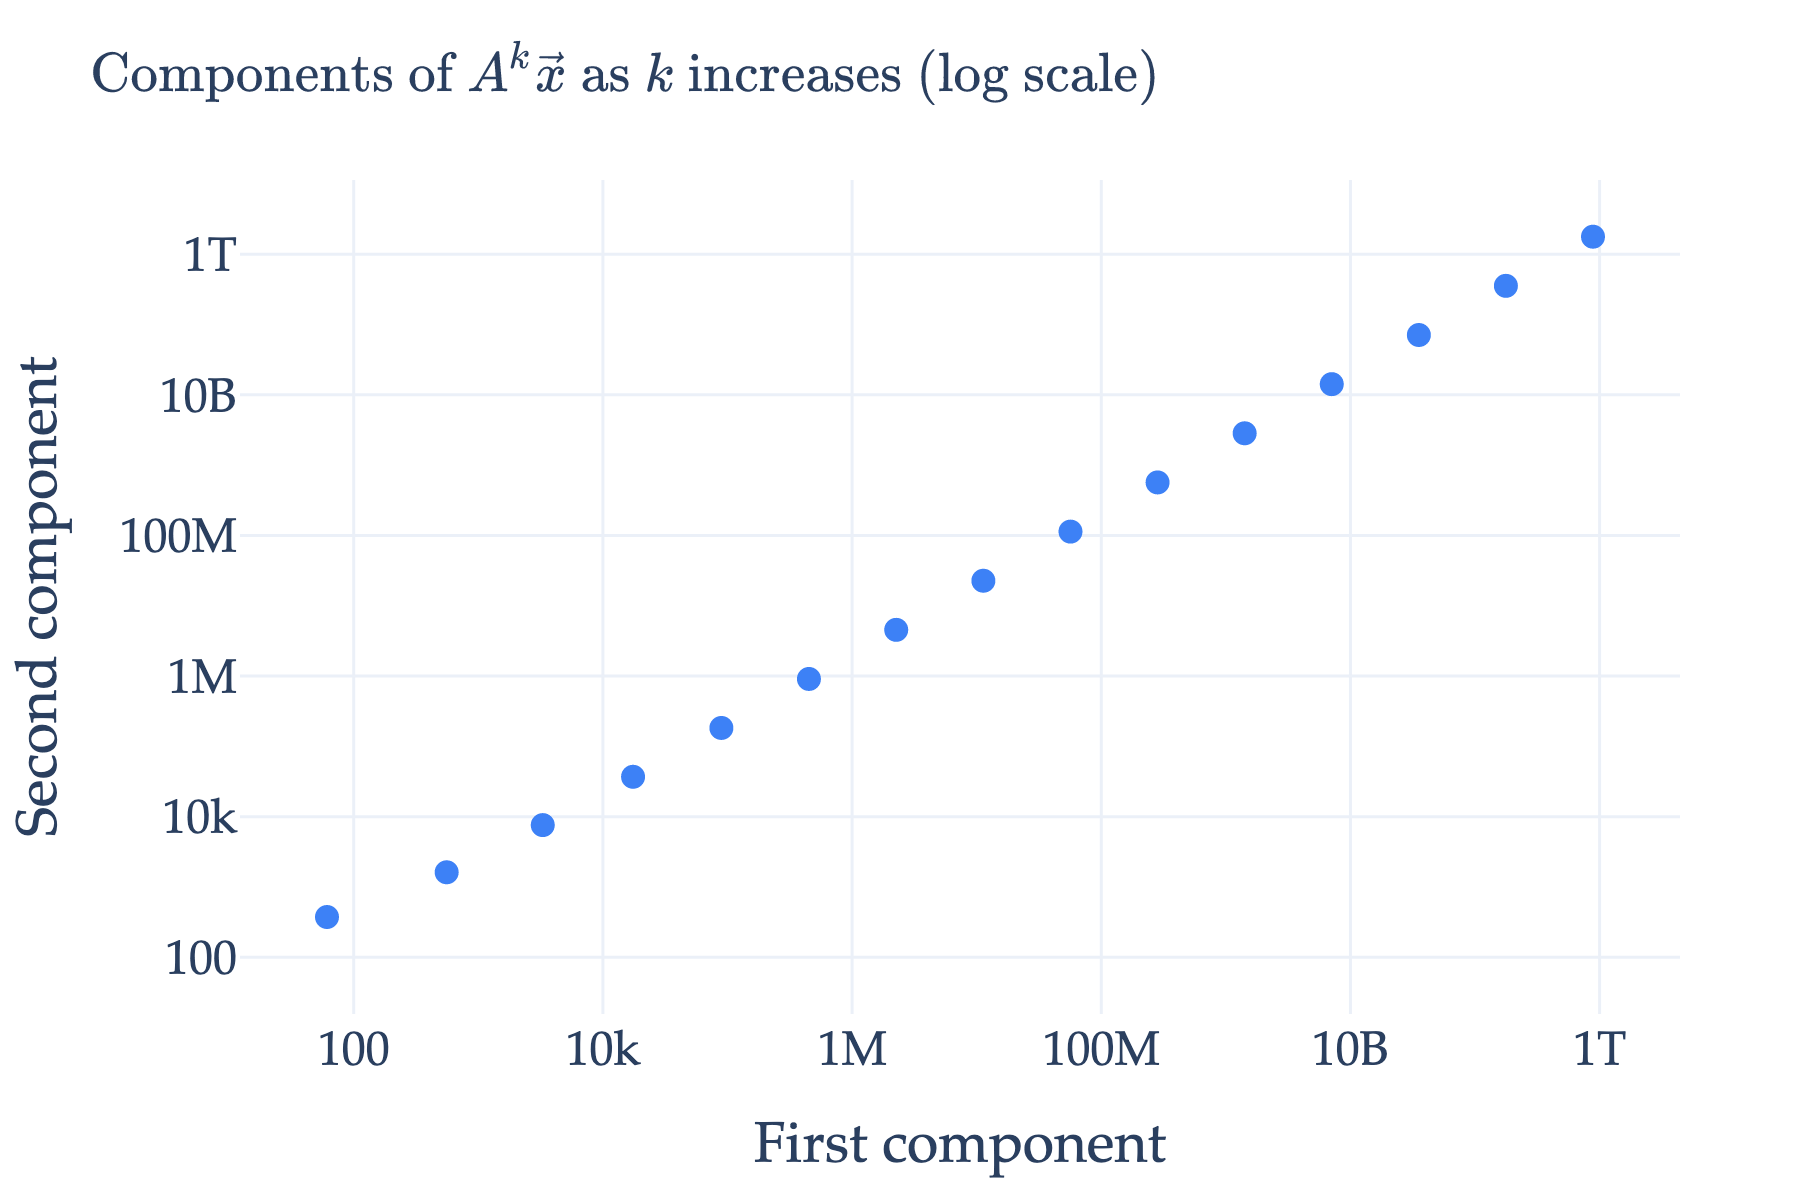

In [9]:
import plotly.graph_objects as go
# This chunk must be in the first plotting cell of each notebook in order to guarantee that the mathjax script is loaded.
import plotly
from IPython.display import display, HTML

# Set default renderer to high-DPI static image
plotly.io.renderers.default = "png"

# Set Palatino font for MathJax and plotly
display(HTML(
    """
    <script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>
    <style>
      .js-plotly-plot .plotly, .js-plotly-plot .plotly .main-svg {
        font-family: 'Palatino Linotype', Palatino, serif;
      }
      mjx-container[jax="SVG"] {
        font-family: 'Palatino Linotype', Palatino, serif !important;
      }
    </style>
    """
))

A = np.array([[3, 1],
              [2, 4]])
x = np.array([[-13], [100]])

x0_vals = []
x1_vals = []

for k in range(16):
    x0_vals.append(float(x[0, 0]))
    x1_vals.append(float(x[1, 0]))
    x = A @ x

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x0_vals,
    y=x1_vals,
    mode='markers',
    name='Trajectory in (x, y) space',
    line=dict(color='#3d81f6'),
    marker=dict(size=8)
))

fig.update_layout(
    title=r'$$\text{Components of } A^k \vec x \text{ as } k \text{ increases (log scale)}$$',
    xaxis_title='First component',
    yaxis_title='Second component',
    width=600,
    height=400,
    margin=dict(l=40, r=40, t=60, b=40),
    font=dict(family="'Palatino Linotype', Palatino, serif", size=16),
    template='plotly_white',
    xaxis_type="log",
    yaxis_type="log"
)

fig.show(renderer='png', scale=3)


I had to log-scale the axes, since the components of $A^k \vec x$ are growing exponentially. But, you should notice that the vectors $A^k \vec x$ all lie on the same line – the line described by the **eigenvector for the dominant eigenvalue**, $\vec v_2 = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$! Hover over any point above to see the coordinates of the vector $A^k \vec x$ for a particular $k$, and you'll see the $y$-coordinate tends to be roughly double the $x$-coordinate.

So, when the dominant eigenvalue (that is, the eigenvalue with the largest magnitude) is greater than 1, the vector $A^k \vec x$ doesn't converge, but its direction converges to the direction of the eigenvector corresponding to the dominant eigenvalue. Through the lens of our most recent equation for $A^k \vec x$,

$$A^k \vec x = c_1 (2)^k \begin{bmatrix} 1 \\ -1 \end{bmatrix} + c_2 (5)^k \begin{bmatrix} 1 \\ 2 \end{bmatrix}$$

Notice that if we divide both sides by $5^k$, we see

$$\frac{A^k \vec x}{5^k} = c_1 \left(\frac{2}{5}\right)^k \begin{bmatrix} 1 \\ -1 \end{bmatrix} + c_2 \begin{bmatrix} 1 \\ 2 \end{bmatrix}$$

And as $k$ increases, the term $c_1 \left(\frac{2}{5}\right)^k$ approaches 0. So, the direction of $\frac{A^k \vec x}{5^k}$ approaches the direction of $\begin{bmatrix} 1 \\ 2 \end{bmatrix}$, but $A^k \vec x$ and $\frac{A^k \vec x}{5^k}$ have the same direction (but different magnitudes).

(I view our approach above as being similar to an approach used in limit problems in Calculus 1. For example, to find $\lim_{x \to \infty} \frac{x^2}{3x^2 - 4x}$, you divide the numerator and denominator by the highest power to get $\lim_{x \to \infty} \frac{1}{3 - 4/x} = 1/3$. This is similar to what we did above, where we divided by the highest power of $5^k$ to make the dominant behavior clear.)

You can view the process of computing $A^k \vec x$ for larger and larger $k$ until the direction stabilizes as being a technique for **approximating** the eigenvector corresponding to the dominant eigenvalue. This is called the **power method**.

**Here's the cliffhanger**: our analysis of the behavior of $A^k \vec x$ as $k$ increases has depended on the eigenvectors of $A$ (that is, $\vec v_1$ and $\vec v_2$) being linearly independent. What if the eigenvectors of a particular matrix aren't linearly independent? Time for [Chapter 9.4](04-multiplicities-diagonalization.ipynb) to shine.